In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# Path to the dataset (adjust if different)
source_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"

# Check if directory exists
if os.path.exists(source_dir):
    print("✅ Dataset found at:", source_dir)
else:
    print("❌ Dataset not found. Please check the path.")


✅ Dataset found at: /content/drive/MyDrive/project/basepaper/EuroSAT


In [ ]:
/L97YU63  `1§§import os
import shutil
import random
from tqdm import tqdm

# Updated dataset path
original_data_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT"
base_split_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_full_split"
split_ratio = (0.7, 0.15, 0.15)  # Train, Val, Test
split_dirs = ['train', 'val', 'test']

# Create split directories if not exist
for split in split_dirs:
    os.makedirs(os.path.join(base_split_dir, split), exist_ok=True)

# Check if already split
already_split = all(
    os.path.exists(os.path.join(base_split_dir, split, class_name))
    for split in split_dirs
    for class_name in os.listdir(original_data_dir)
    if os.path.isdir(os.path.join(original_data_dir, class_name))
)

if not already_split:
    print("📂 Splitting full dataset into train, val, and test folders...")

    class_names = os.listdir(original_data_dir)
    for class_name in tqdm(class_names, desc="Splitting"):
        class_dir = os.path.join(original_data_dir, class_name)
        if not os.path.isdir(class_dir):
            continue

        images = sorted(os.listdir(class_dir))
        images = [img for img in images if img.lower().endswith((".jpg", ".jpeg", ".png"))]
        random.shuffle(images)

        n_total = len(images)
        n_train = int(n_total * split_ratio[0])
        n_val = int(n_total * split_ratio[1])

        split_paths = {
            'train': images[:n_train],
            'val': images[n_train:n_train + n_val],
            'test': images[n_train + n_val:]
        }

        for split in split_dirs:
            split_class_dir = os.path.join(base_split_dir, split, class_name)
            os.makedirs(split_class_dir, exist_ok=True)
            for img_name in split_paths[split]:
                src_path = os.path.join(class_dir, img_name)
                dst_path = os.path.join(split_class_dir, img_name)
                shutil.copy(src_path, dst_path)

    print("✅ Dataset split completed successfully.")
else:
    print("✅ Dataset already split. Skipping splitting.")


✅ Dataset already split. Skipping splitting.


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Epoch 1 Training: 100%|██████████| 2376/2376 [8:45:44<00:00, 13.28s/it]


[Epoch 1] Train Acc: 0.8638, Val Acc: 0.9644


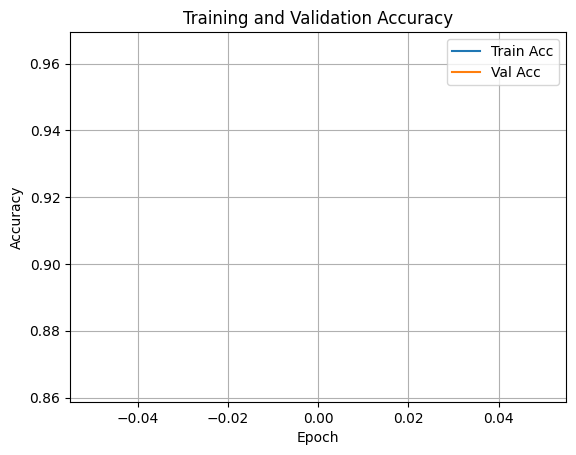

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from timm import create_model
import torch.nn as nn
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Updated dataset path (after split)
base_split_dir = "/content/drive/MyDrive/project/basepaper/EuroSAT_full_split"

# Transform
transform = transforms.Compose([
    transforms.Resize((300, 300)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Datasets & Loaders
train_dataset = datasets.ImageFolder(os.path.join(base_split_dir, 'train'), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(base_split_dir, 'val'), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Model
model = create_model('efficientnet_b4', pretrained=True, num_classes=10)
model = model.to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Training
num_epochs = 1
train_acc_history = []
val_acc_history = []

for epoch in range(num_epochs):
    model.train()
    train_loss, train_correct = 0.0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / len(train_dataset)
    train_acc_history.append(train_acc)

    # Validation
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc = val_correct / len(val_dataset)
    val_acc_history.append(val_acc)

    print(f"[Epoch {epoch+1}] Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

# Accuracy Plot
plt.plot(train_acc_history, label='Train Acc')
plt.plot(val_acc_history, label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()
